# BERT Fine-tuning — Fake News Detection
**Esha Hooda (014796990) | Tyler Biesemeyer (016488979) | Tarif Khan (017050683)**

> **Before running:** Go to `Runtime → Change runtime type → T4 GPU → Save`

Run cells **one at a time, top to bottom.**

## Cell 1 — Install

In [1]:
!pip install transformers kagglehub scikit-learn pandas matplotlib nltk seaborn torch -q
print('Done.')

Done.


## Cell 2 — Imports

In [2]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, classification_report, confusion_matrix)
import seaborn as sns
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (BertTokenizer, BertForSequenceClassification,
                           get_linear_schedule_with_warmup)
import kagglehub
from kagglehub import KaggleDatasetAdapter

nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cpu':
    print('⚠️  WARNING: No GPU detected. Go to Runtime → Change runtime type → T4 GPU')
else:
    print('✅ GPU ready.')

Using device: cuda
✅ GPU ready.


## Cell 3 — Load & Preprocess Data

In [4]:
print('Loading dataset...')
df_fake = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS,
                                  'clmentbisaillon/fake-and-real-news-dataset', 'Fake.csv')
df_true = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS,
                                  'clmentbisaillon/fake-and-real-news-dataset', 'True.csv')
# df_fake = pd.read_csv('Fake.csv')
# df_true = pd.read_csv('True.csv')
df_fake['label'] = 0
df_true['label'] = 1
df = pd.concat([df_fake, df_true], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
print(f'Loaded {len(df):,} samples — Fake: {(df.label==0).sum():,} | Real: {(df.label==1).sum():,}')

stop_words = set(stopwords.words('english'))
def clean_text(text):
    if not isinstance(text, str): return ''
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

df['combined'] = df['title'].astype(str) + ' ' + df['text'].astype(str)
df = df[df['combined'].str.strip() != ''].reset_index(drop=True)
print('Cleaning text... (takes ~1 min)')
df['clean_text'] = df['combined'].apply(clean_text)
df = df[df['clean_text'].str.strip() != ''].reset_index(drop=True)
print(f'Done. {len(df):,} samples after cleaning.')

Loading dataset...


/tmp/ipykernel_450/2150146228.py:2: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_fake = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS,


100%|██████████| 22.9M/22.9M [00:00<00:00, 52.7MB/s]

Extracting zip of Fake.csv...



/tmp/ipykernel_450/2150146228.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_true = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS,


100%|██████████| 18.1M/18.1M [00:00<00:00, 56.0MB/s]

Extracting zip of True.csv...


Loaded 44,898 samples — Fake: 23,481 | Real: 21,417
Cleaning text... (takes ~1 min)
Done. 44,889 samples after cleaning.


## Cell 4 — Train/Val/Test Split

In [5]:
MAX_SAMPLES = 20000
df_f = df[df.label==0].sample(n=min(MAX_SAMPLES//2, (df.label==0).sum()), random_state=42)
df_t = df[df.label==1].sample(n=min(MAX_SAMPLES//2, (df.label==1).sum()), random_state=42)
df_sample = pd.concat([df_f, df_t]).sample(frac=1, random_state=42).reset_index(drop=True)

X = df_sample['clean_text'].values
y = df_sample['label'].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
X_val,   X_test,  y_val,   y_test  = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f'Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}')

Train: 16,000 | Val: 2,000 | Test: 2,000


## Cell 5 — BERT Config + Dataset + Model

In [6]:
# ── Hyperparameters ───────────────────────────────────────────────
BERT_MODEL_NAME = 'bert-base-uncased'
BERT_MAX_LEN    = 256
BERT_BATCH_SIZE = 8
BERT_EPOCHS     = 3
BERT_LR         = 2e-5
BERT_TRAIN_SIZE = 16000
BERT_VAL_SIZE   = 2000
BERT_TEST_SIZE  = 2000

print('BERT Hyperparameters:')
print(f'  Model      : {BERT_MODEL_NAME}')
print(f'  Max length : {BERT_MAX_LEN} tokens')
print(f'  Batch size : {BERT_BATCH_SIZE}')
print(f'  Epochs     : {BERT_EPOCHS}')
print(f'  LR         : {BERT_LR}')
print(f'  Train size : {BERT_TRAIN_SIZE:,}')

# ── Subset ────────────────────────────────────────────────────────
X_bert_train = list(X_train[:BERT_TRAIN_SIZE])
y_bert_train = list(y_train[:BERT_TRAIN_SIZE])
X_bert_val   = list(X_val[:BERT_VAL_SIZE])
y_bert_val   = list(y_val[:BERT_VAL_SIZE])
X_bert_test  = list(X_test[:BERT_TEST_SIZE])
y_bert_test  = list(y_test[:BERT_TEST_SIZE])

# ── Dataset class ─────────────────────────────────────────────────
bert_tokenizer = BertTokenizer.from_pretrained(BERT_MODEL_NAME)

class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts; self.labels = labels
        self.tokenizer = tokenizer; self.max_len = max_len
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'label':          torch.tensor(int(self.labels[idx]), dtype=torch.long)
        }

train_dataset = NewsDataset(X_bert_train, y_bert_train, bert_tokenizer, BERT_MAX_LEN)
val_dataset   = NewsDataset(X_bert_val,   y_bert_val,   bert_tokenizer, BERT_MAX_LEN)
test_dataset  = NewsDataset(X_bert_test,  y_bert_test,  bert_tokenizer, BERT_MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BERT_BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BERT_BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BERT_BATCH_SIZE, shuffle=False)

# ── Model ─────────────────────────────────────────────────────────
bert_model = BertForSequenceClassification.from_pretrained(BERT_MODEL_NAME, num_labels=2)
bert_model = bert_model.to(device)

# ── Optimizer + scheduler ─────────────────────────────────────────
optimizer    = AdamW(bert_model.parameters(), lr=BERT_LR, weight_decay=0.01)
total_steps  = len(train_loader) * BERT_EPOCHS
warmup_steps = total_steps // 10
scheduler    = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

print(f'\nModel loaded. Trainable params: {sum(p.numel() for p in bert_model.parameters() if p.requires_grad):,}')
print(f'Total steps: {total_steps} | Warmup steps: {warmup_steps}')
print('\n✅ Cell 5 complete. Run Cell 6 next.')

BERT Hyperparameters:
  Model      : bert-base-uncased
  Max length : 256 tokens
  Batch size : 8
  Epochs     : 3
  LR         : 2e-05
  Train size : 16,000


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Model loaded. Trainable params: 109,483,778
Total steps: 6000 | Warmup steps: 600

✅ Cell 5 complete. Run Cell 6 next.


## Cell 6 — Train BERT
>  With GPU: ~15-20 min total. You will see step-by-step loss printed. Wait for `Epoch 3/3 Complete` before running Cell 7.

In [12]:
# ── Evaluate helper ───────────────────────────────────────────────
def bert_evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)
            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask,
                            labels=labels)
            total_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return (total_loss / len(loader),
            accuracy_score(all_labels, all_preds),
            np.array(all_preds),
            np.array(all_labels))

# ── Training tracking lists ───────────────────────────────────────
bert_train_accs,   bert_val_accs   = [], []
bert_train_losses, bert_val_losses = [], []

print(f'Starting BERT fine-tuning — {BERT_EPOCHS} epochs, {len(train_loader)} steps/epoch')
print(f'Device: {device}\n')

for epoch in range(BERT_EPOCHS):
    # ── Training phase ────────────────────────────────────────────
    bert_model.train()
    total_train_loss   = 0
    train_preds        = []
    train_labels_ep    = []

    for step, batch in enumerate(train_loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = bert_model(input_ids=input_ids,
                             attention_mask=attention_mask,
                             labels=labels)
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_train_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_labels_ep.extend(labels.cpu().numpy())

        if (step + 1) % 50 == 0:
            print(f'  Epoch {epoch+1}/{BERT_EPOCHS} | '
                  f'Step {step+1}/{len(train_loader)} | '
                  f'Loss: {loss.item():.4f}')

    # ── Epoch summary ─────────────────────────────────────────────
    train_acc  = accuracy_score(train_labels_ep, train_preds)
    train_loss = total_train_loss / len(train_loader)
    val_loss, val_acc, _, _ = bert_evaluate(bert_model, val_loader, device)

    bert_train_accs.append(train_acc)
    bert_val_accs.append(val_acc)
    bert_train_losses.append(train_loss)
    bert_val_losses.append(val_loss)

    print(f'\n>>> Epoch {epoch+1}/{BERT_EPOCHS} Complete')
    print(f'    Train — Loss: {train_loss:.4f} | Acc: {train_acc:.4f}')
    print(f'    Val   — Loss: {val_loss:.4f}   | Acc: {val_acc:.4f}\n')

print('='*50)
print('✅ Training complete! Run Cell 7 now.')
print('='*50)

Starting BERT fine-tuning — 3 epochs, 2000 steps/epoch
Device: cuda

  Epoch 1/3 | Step 50/2000 | Loss: 0.0000
  Epoch 1/3 | Step 100/2000 | Loss: 0.0000
  Epoch 1/3 | Step 150/2000 | Loss: 0.0000
  Epoch 1/3 | Step 200/2000 | Loss: 0.0000
  Epoch 1/3 | Step 250/2000 | Loss: 0.0000
  Epoch 1/3 | Step 300/2000 | Loss: 0.0000
  Epoch 1/3 | Step 350/2000 | Loss: 0.0000
  Epoch 1/3 | Step 400/2000 | Loss: 0.0000
  Epoch 1/3 | Step 450/2000 | Loss: 0.0000
  Epoch 1/3 | Step 500/2000 | Loss: 0.0000
  Epoch 1/3 | Step 550/2000 | Loss: 0.0000
  Epoch 1/3 | Step 600/2000 | Loss: 0.0000
  Epoch 1/3 | Step 650/2000 | Loss: 0.0000
  Epoch 1/3 | Step 700/2000 | Loss: 0.0000
  Epoch 1/3 | Step 750/2000 | Loss: 0.0000
  Epoch 1/3 | Step 800/2000 | Loss: 0.0000
  Epoch 1/3 | Step 850/2000 | Loss: 0.0000
  Epoch 1/3 | Step 900/2000 | Loss: 0.0000
  Epoch 1/3 | Step 950/2000 | Loss: 0.0000
  Epoch 1/3 | Step 1000/2000 | Loss: 0.0000
  Epoch 1/3 | Step 1050/2000 | Loss: 0.0000
  Epoch 1/3 | Step 1100/200

## Cell 7 — Training Curves

Epochs recorded: 3
bert_train_accs : [0.9726, 0.9989, 0.9995]
bert_val_accs   : [0.998, 0.9985, 0.9985]


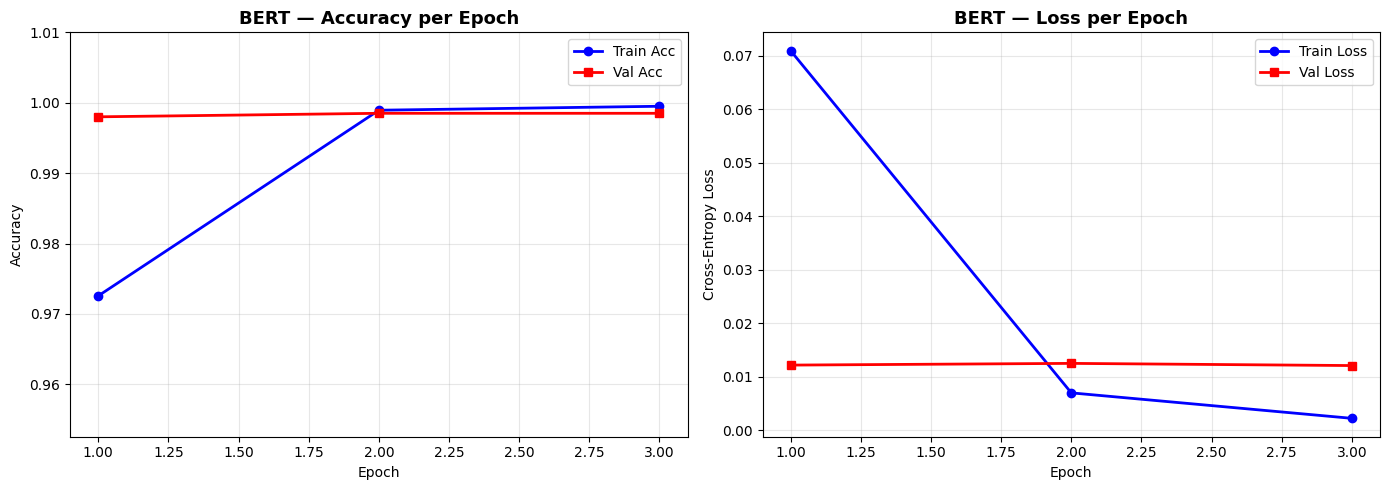

Curves saved to bert_curves.png


In [8]:
print(f'Epochs recorded: {len(bert_train_accs)}')
print(f'bert_train_accs : {[round(x,4) for x in bert_train_accs]}')
print(f'bert_val_accs   : {[round(x,4) for x in bert_val_accs]}')

ep_range = range(1, len(bert_train_accs) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ep_range, bert_train_accs,   'b-o', label='Train Acc', lw=2)
axes[0].plot(ep_range, bert_val_accs,     'r-s', label='Val Acc',   lw=2)
axes[0].set_title('BERT — Accuracy per Epoch', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(min(min(bert_train_accs), min(bert_val_accs)) - 0.02, 1.01)

axes[1].plot(ep_range, bert_train_losses, 'b-o', label='Train Loss', lw=2)
axes[1].plot(ep_range, bert_val_losses,   'r-s', label='Val Loss',   lw=2)
axes[1].set_title('BERT — Loss per Epoch', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Cross-Entropy Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('bert_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Curves saved to bert_curves.png')

## Cell 8 — Test Evaluation + Confusion Matrix

  BERT FINAL TEST RESULTS
  Accuracy  : 0.9985
  Precision : 0.9980
  Recall    : 0.9990
  F1-Score  : 0.9985

              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      1000
        Real       1.00      1.00      1.00      1000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



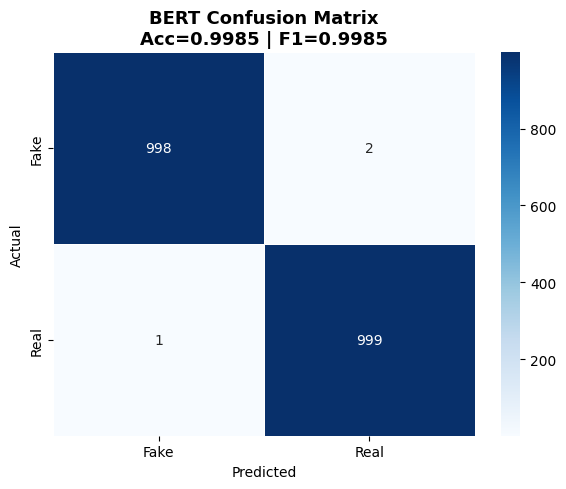

Confusion matrix saved.


In [13]:
_, _, bert_preds, bert_true = bert_evaluate(bert_model, test_loader, device)

acc  = accuracy_score(bert_true, bert_preds)
f1   = f1_score(bert_true, bert_preds)
prec = precision_score(bert_true, bert_preds)
rec  = recall_score(bert_true, bert_preds)

print('='*50)
print('  BERT FINAL TEST RESULTS')
print('='*50)
print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'\n{classification_report(bert_true, bert_preds, target_names=["Fake","Real"])}')

# Confusion matrix
cm = confusion_matrix(bert_true, bert_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake','Real'], yticklabels=['Fake','Real'],
            linewidths=0.5)
plt.title(f'BERT Confusion Matrix\nAcc={acc:.4f} | F1={f1:.4f}',
          fontweight='bold', fontsize=13)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('bert_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrix saved.')

## Cell 9 — Save Model

In [14]:
bert_model.save_pretrained('bert_fake_news_model/')
bert_tokenizer.save_pretrained('bert_fake_news_model/')
print('✅ BERT model saved to bert_fake_news_model/')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ BERT model saved to bert_fake_news_model/


## Cell 10 — Inference Demo

In [15]:
def predict_bert(text):
    bert_model.eval()
    enc = bert_tokenizer(
        text, max_length=BERT_MAX_LEN,
        padding='max_length', truncation=True, return_tensors='pt'
    )
    with torch.no_grad():
        out = bert_model(
            input_ids=enc['input_ids'].to(device),
            attention_mask=enc['attention_mask'].to(device)
        )
    probs = torch.softmax(out.logits, dim=1).cpu().numpy()[0]
    label = 'REAL' if probs[1] >= 0.5 else 'FAKE'
    return label, float(max(probs))

samples = [
    ("Reuters: The Federal Reserve raised interest rates by 25 basis points citing persistent inflation.",
     'Expected: REAL'),
    ("SHOCKING: Government hiding miracle cure!! Share before they delete this!!! Big pharma conspiracy EXPOSED",
     'Expected: FAKE'),
    ("President signs new infrastructure bill allocating funds for roads and broadband expansion.",
     'Expected: REAL'),
]

print('='*60)
print('BERT INFERENCE DEMO')
print('='*60)
for text, expected in samples:
    label, conf = predict_bert(text)
    print(f'\nText    : "{text[:70]}..."')
    print(f'{expected}')
    print(f'BERT    : {label} (confidence: {conf:.1%})')

BERT INFERENCE DEMO

Text    : "Reuters: The Federal Reserve raised interest rates by 25 basis points ..."
Expected: REAL
BERT    : REAL (confidence: 100.0%)

Text    : "SHOCKING: Government hiding miracle cure!! Share before they delete th..."
Expected: FAKE
BERT    : FAKE (confidence: 100.0%)

Text    : "President signs new infrastructure bill allocating funds for roads and..."
Expected: REAL
BERT    : REAL (confidence: 99.9%)
